# ARTI308 Lab 4 Assignment
Data Quality Assessment & Preprocessing
Dataset: Boston Housing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load Dataset

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## Task 1: Data Quality Issues

In [3]:
df.dtypes

,0
crim,float64
zn,float64
indus,float64
chas,int64
nox,float64
rm,float64
age,float64
dis,float64
rad,int64
tax,int64


In [4]:
df.isna().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [5]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Dataset inspection shows:
- All features are numeric
- No missing values exist
- Some extreme values appear

## Task 2: Missing Values Strategy

In [6]:
df_missing=df.copy()

df_missing.loc[0:5,'medv']=np.nan

df_imputed=df_missing.copy()

df_imputed['medv']=df_imputed['medv'].fillna(df_imputed['medv'].median())

df_imputed.isna().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


Median imputation was used because it is robust to outliers.

## Task 3: Outliers using IQR

In [7]:
Q1=df['medv'].quantile(0.25)
Q3=df['medv'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df[(df['medv']<lower)|(df['medv']>upper)]

outliers.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
97,0.12083,0.0,2.89,0,0.445,8.069,76.0,3.4952,2,276,18.0,396.90,4.21,38.7
98,0.08187,0.0,2.89,0,0.445,7.820,36.9,3.4952,2,276,18.0,393.53,3.57,43.8
157,1.22358,0.0,19.58,0,0.605,6.943,97.4,1.8773,5,403,14.7,363.43,4.59,41.3
161,1.46336,0.0,19.58,0,0.605,7.489,90.8,1.9709,5,403,14.7,374.43,1.73,50.0
162,1.83377,0.0,19.58,1,0.605,7.802,98.2,2.0407,5,403,14.7,389.61,1.92,50.0


In [8]:
df_no_outliers=df[(df['medv']>=lower)&(df['medv']<=upper)]

print("Original shape:",df.shape)
print("After removing outliers:",df_no_outliers.shape)

Original shape: (506, 14)
After removing outliers: (466, 14)


Outliers detected using IQR method.

## Task 4: Normalization

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

df_minmax=df[['rm','medv']].copy()

df_minmax[['rm','medv']]=scaler.fit_transform(df_minmax)

df_minmax.head()

,rm,medv
0,0.577505,0.422222
1,0.547998,0.368889
2,0.694386,0.660000
3,0.658555,0.631111
4,0.687105,0.693333


In [10]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

df_zscore=df[['rm','medv']].copy()

df_zscore[['rm','medv']]=scaler.fit_transform(df_zscore)

df_zscore.head()

,rm,medv
0,0.413672,0.159686
1,0.194274,-0.101524
2,1.282714,1.324247
3,1.016303,1.182758
4,1.228577,1.487503


Min-Max and Z-score normalization applied.

## Task 5: PCA

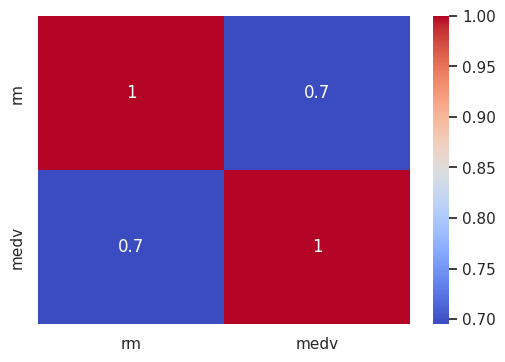

In [11]:
plt.figure(figsize=(6,4))

sns.heatmap(df_zscore.corr(),annot=True,cmap="coolwarm")

plt.show()

In [12]:
from sklearn.decomposition import PCA

X=df_zscore[['rm','medv']]

pca=PCA(n_components=2)

pc=pca.fit_transform(X)

print("Explained Variance Ratio:",pca.explained_variance_ratio_)

Explained Variance Ratio: [0.84767997 0.15232003]
